# Fase 4 — Modelado y validación honesta

**Notebook de lectura y visualización.** Todo lo que se muestra aquí ya está calculado y guardado en
disco por los scripts de la Fase 4 (`old_scripts/04_run_modeling_sweep.py` y
`old_scripts/05_nested_cv_and_freeze.py`). Este notebook **no entrena nada**: abre los CSV de
resultados, el modelo congelado y su ficha, y los convierte en figuras para la tesis.

## De dónde viene y qué produce

- **Entra:** la matriz de features de la Fase 3 — `data_processed/features.parquet`,
  34 000 filas (17 pacientes × 2 000 épocas de 10 s) × 380 features espectrales y temporales.
- **Sale:** un modelo **congelado** (`models/frozen_model.joblib`) con su ficha, y una
  **estimación honesta** de cuánto discrimina, obtenida por **validación cruzada anidada** con
  **LOPO externo** (*leave-one-patient-out*: cada paciente es, por turnos, el único paciente de test).
- **Tarea:** pronóstico binario por paciente — `1` = despertará (*good*), `0` = no (*poor*) — más
  una **confianza** (la probabilidad promediada sobre las épocas del paciente).
- **Muestra de desarrollo:** 17 pacientes (9 *good* / 8 *poor*). Los 15 pacientes *held-out* de la
  Fase 5 **no se tocan aquí**.

## ⚠️ El resultado de esta fase es NEGATIVO — y se reporta como tal

La estimación honesta da **AUC a nivel de paciente = 0.556, IC 95 % [0.242, 0.848]**. Juzgado contra
la **distribución nula empírica del propio protocolo** (§2), el observado queda **por encima del
azar real (0.389) pero muy por debajo del percentil 95 (0.683)**: **p = 0.1782, sin evidencia de
discriminación**. Además, el modelo predice *good* en 15 de 17 pacientes (**sensibilidad 1.000 /
especificidad 0.250**), es decir, reproduce el balance de clases más que discriminar.

Un resultado negativo **bien medido** es un resultado válido para una prueba de concepto. El
objetivo de este notebook es que ese hecho se vea a simple vista, no maquillarlo.

## ⚠️ El azar de este protocolo NO está en 0.5

Antes de leer ninguna figura hay que interiorizar §2: bajo **LOPO** el azar real está en **≈0.39**,
no en 0.5, porque sacar a un paciente desbalancea el train contra su propia clase. Comparar
cualquier AUC de este notebook contra 0.5 **da una lectura falsamente catastrófica**. Es un sesgo
**conservador** (hunde resultados, no los infla), y por eso todas las figuras usan como referencia la
**nula LOPO empírica**, no el 0.5 teórico.

## Dos niveles de evidencia — no confundirlos

| | Barrido de configuraciones | CV anidada |
|---|---|---|
| Archivo | `modeling_sweep*.csv` | `nested_cv_patient_predictions.csv` |
| Qué es | **exploración** | **estimación honesta** |
| Sesgo | **al alza**: el ganador se elige mirando la misma métrica que se reporta | la elección del modelo ocurre **dentro** de cada fold externo |
| Uso | orientar decisiones de diseño | el número que se reporta en la tesis |

## 0. Preparación del entorno

Importaciones, rutas y estilo gráfico. Se añade `src/` al `sys.path` para poder reutilizar las
funciones de métricas de `validation.py` (las mismas que produjeron los números guardados), de modo
que lo que se dibuja aquí sea **exactamente** lo que se calculó, no una reimplementación paralela.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# --- Resolucion robusta de rutas: sube hasta encontrar development/ ----------
# Asi el notebook corre tanto desde notebooks/ como desde development/.
_here = Path.cwd()
DEV_DIR = next(
    (p for p in (_here, *_here.parents) if (p / "data_processed").is_dir()),
    _here,
)
DATA_DIR = DEV_DIR / "data_processed"
MODELS_DIR = DEV_DIR / "models"
sys.path.insert(0, str(DEV_DIR / "src"))

import validation as val  # noqa: E402  (despues de tocar sys.path)

# --- Estilo grafico comun ----------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Paleta fija del proyecto: good vs poor, y acentos neutros.
C_GOOD, C_POOR = "#1f77b4", "#d95f02"
C_CHANCE, C_MODEL = "#888888", "#2c7d59"

print(f"development/ -> {DEV_DIR}")
print(f"validation.py cargado desde {val.__file__}")

development/ -> /home/singular1ty/Documents/projects/ongoing_projects/eeg-ml-project/development
validation.py cargado desde /home/singular1ty/Documents/projects/ongoing_projects/eeg-ml-project/development/src/validation.py


## 1. Carga de los resultados guardados

Seis insumos, todos de **solo lectura**:

1. `modeling_sweep.csv` — el barrido completo: clasificador × estrategia de reducción × nº de épocas.
2. `modeling_sweep_epochs.csv` — el sub-barrido que varía sólo el nº de épocas por paciente.
3. `nested_cv_patient_predictions.csv` — las 17 predicciones *out-of-fold* de la CV anidada. **Ésta
   es la fuente de la estimación honesta.**
4. `models/frozen_model.json` — la ficha del modelo congelado: criterio de selección, métricas,
   p-valor de permutación, lectura honesta.
5. `lopo_null_aucs.npy` — **100 AUC nulas del protocolo primario LOPO**: la referencia de "azar"
   real contra la que hay que juzgarlo todo (§2).
6. `permutation_null_aucs.npy` — las 200 AUC nulas del test de permutación con
   `StratifiedGroupKFold(5)` (§9).

In [2]:
sweep = pd.read_csv(DATA_DIR / "modeling_sweep.csv")
sweep_epochs = pd.read_csv(DATA_DIR / "modeling_sweep_epochs.csv")
# patient_id es un codigo con ceros a la izquierda ('0284'), no un entero.
patients = pd.read_csv(
    DATA_DIR / "nested_cv_patient_predictions.csv", dtype={"patient_id": str}
)
with open(MODELS_DIR / "frozen_model.json", encoding="utf-8") as fh:
    frozen = json.load(fh)

# Distribuciones nulas EMPIRICAS (valores reales guardados en disco, no aproximaciones).
lopo_null = np.load(DATA_DIR / "lopo_null_aucs.npy")
perm_null = np.load(DATA_DIR / "permutation_null_aucs.npy")

print(f"sweep              : {sweep.shape[0]} filas x {sweep.shape[1]} columnas")
print(f"sweep_epochs       : {sweep_epochs.shape[0]} filas")
print(f"patients (nested)  : {patients.shape[0]} pacientes")
print(f"nula LOPO          : {lopo_null.size} valores")
print(f"nula permutacion   : {perm_null.size} valores")
print(f"columnas del sweep : {list(sweep.columns)}")

# NOTA: la columna `patient_brier` esta VACIA en estos CSV. Era un bug del
# barrido (leia la clave 'brier' en vez de 'brier_score'); ya corregido en
# src/modeling.py, pero el barrido no se ha re-ejecutado. No se usa aqui.
n_brier = sweep["patient_brier"].notna().sum()
print(f"\n[aviso] patient_brier no vacios: {n_brier}/{len(sweep)} "
      "-> columna inservible en estos CSV (bug ya corregido, barrido sin re-ejecutar)")
print()
print(patients.to_string(index=False))

sweep              : 84 filas x 12 columnas
sweep_epochs       : 36 filas
patients (nested)  : 17 pacientes
nula LOPO          : 100 valores
nula permutacion   : 200 valores
columnas del sweep : ['n_epochs_per_patient', 'reduction', 'classifier', 'patient_auc', 'patient_balacc', 'patient_sens', 'patient_spec', 'patient_brier', 'epoch_auc', 'epoch_balacc', 'seconds', 'status']

[aviso] patient_brier no vacios: 0/84 -> columna inservible en estos CSV (bug ya corregido, barrido sin re-ejecutar)

patient_id  n_epochs  prob_good  pred  y_true
      0284       200   0.551632     1       1
      0286       200   0.739373     1       1
      0299       200   0.919758     1       1
      0311       200   0.807540     1       1
      0319       200   0.647097     1       1
      0335       200   0.520214     1       1
      0337       200   0.573161     1       1
      0344       200   0.588263     1       0
      0346       200   0.275307     0       0
      0348       200   0.160940     0     

In [3]:
# --- Ficha del modelo congelado ---------------------------------------------
nested_metrics = frozen["nested_cv_patient_metrics"]

print("MODELO CONGELADO")
print(f"  clasificador      : {frozen['classifier']}")
print(f"  reduccion         : {frozen['reduction']}  ({frozen['n_features_in']} features de entrada)")
print(f"  epocas/paciente   : {frozen['epochs_per_patient']}  (filas ajustadas: {frozen['n_rows_fitted']})")
print(f"  agregacion        : {frozen['aggregation_rule']}   umbral: {frozen['decision_threshold']}")
print(f"  semilla           : {frozen['random_seed']}")
print(f"  congelado el      : {frozen['created']}")
print()
print("METRICAS DE LA CV ANIDADA (nivel paciente, N=17)")
for key in ("roc_auc", "balanced_accuracy", "accuracy", "sensitivity", "specificity", "brier_score"):
    print(f"  {key:20s} {nested_metrics[key]:.3f}")
print(f"  matriz            tn={int(nested_metrics['tn'])} fp={int(nested_metrics['fp'])} "
      f"fn={int(nested_metrics['fn'])} tp={int(nested_metrics['tp'])}")
print()
print("CRITERIO DE SELECCION")
print(f"  {frozen['selection_criterion']}")
print()
print("LECTURA HONESTA (guardada en la propia ficha)")
print(f"  {frozen['honest_reading']}")

MODELO CONGELADO
  clasificador      : hgb_depth3
  reduccion         : channel_agg  (380 features de entrada)
  epocas/paciente   : 200  (filas ajustadas: 3400)
  agregacion        : mean   umbral: 0.5
  semilla           : 42
  congelado el      : 2026-07-23T18:36:23

METRICAS DE LA CV ANIDADA (nivel paciente, N=17)
  roc_auc              0.556
  balanced_accuracy    0.625
  accuracy             0.647
  sensitivity          1.000
  specificity          0.250
  brier_score          0.252
  matriz            tn=2 fp=6 fn=0 tp=9

CRITERIO DE SELECCION
  Modelo mas votado por la CV anidada (seleccion DENTRO de cada fold externo LOPO), sobre features agregadas por canal (380->20) y 200 epocas/paciente. Criterio fijado ANTES de mirar el held-out.

LECTURA HONESTA (guardada en la propia ficha)
  La CV anidada NO muestra discriminacion por encima del azar. El modelo se congela para poder aplicar el protocolo de Fase 5 sobre el held-out, no porque haya evidencia de senal.


## 2. ¿Cuál es el azar de verdad en este protocolo?

**Antes de medir nada hay que calibrar la regla.** El reflejo automático es comparar cualquier AUC
contra 0.5. En este protocolo **eso es incorrecto**, y el propio barrido lo delata.

### La pista: el `dummy_majority` da AUC = 0.000, no 0.5

El clasificador tonto (`strategy="prior"`: predice la proporción de clases del fold de
entrenamiento) sale con AUC **exactamente 0.000**. No es un error de código, es aritmética de LOPO:

- al dejar fuera a un paciente ***good***, el train queda 8/8 → probabilidad de *good* = **0.5000**;
- al dejar fuera a un paciente ***poor***, el train queda 9/7 → probabilidad de *good* = **0.5625**.

Es decir: **todos los *poor* reciben una probabilidad de "good" MAYOR que todos los *good***. Orden
perfectamente invertido → AUC 0.

### La consecuencia: LOPO deprime el AUC

Ese mismo mecanismo actúa, atenuado, sobre cualquier clasificador: **el mero hecho de sacar a un
paciente desbalancea el train en contra de su propia clase**. Con 17 sujetos el efecto es grande.
Por eso 49 de las 68 configuraciones no-*dummy* del barrido caen por debajo de 0.5 (mediana 0.451):
no es que 49 modelos sean "peores que el azar", es que **la referencia no está en 0.5**.

**Es un sesgo CONSERVADOR**: hunde los resultados, no los infla. Nunca podría fabricar una señal
falsa — pero sí puede hacer que un resultado nulo parezca catastrófico, y eso es un flanco
innecesario en la defensa.

### La solución: medir el azar en vez de suponerlo

`old_scripts/06_lopo_null_distribution.py` baraja las etiquetas **a nivel de paciente** y repite el
**protocolo LOPO completo** 100 veces con `hgb_depth3`. El resultado es la distribución nula
**empírica** del protocolo primario:

| | valor |
|---|---|
| media / mediana | **0.388 / 0.389** |
| desviación típica | **0.171** |
| percentil 5 / 95 | **0.124 / 0.683** |
| AUC observado | **0.556** |
| p empírico | **0.1782** |

**Ésta —y no el 0.5— es la referencia de azar que usa el resto del notebook.**

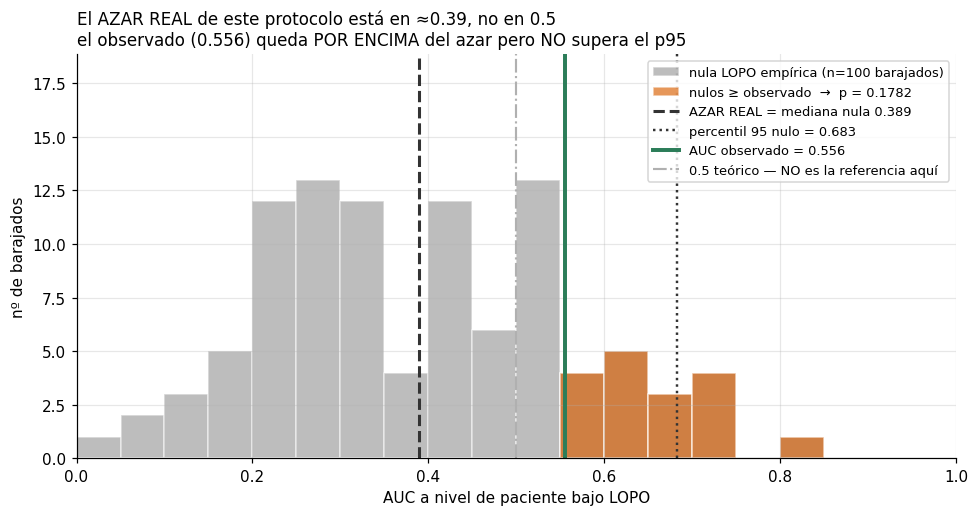

nula LOPO : media=0.388  sd=0.171  mediana=0.389  n=100
percentiles: p5=0.124  p50=0.389  p95=0.683
observado 0.556  ->  z = +0.98 sd sobre la media nula
p empirico = 0.1782  ->  NO se rechaza la hipotesis nula

el 0.5 teorico cae en el percentil 70 de la nula: un modelo que 'empate a 0.5' ya estaria por encima del azar de este protocolo


In [4]:
# --- FIGURA 1: distribucion nula EMPIRICA del protocolo LOPO ----------------
LOPO_OBS = float(nested_metrics["roc_auc"])       # 0.556, el observado del protocolo primario
lopo_mean, lopo_sd = lopo_null.mean(), lopo_null.std(ddof=1)
lopo_p5, lopo_p50, lopo_p95 = np.percentile(lopo_null, [5, 50, 95])
lopo_p = (1 + int((lopo_null >= LOPO_OBS).sum())) / (1 + lopo_null.size)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(lopo_null, bins=20, range=(0, 1), color=C_CHANCE, alpha=0.55,
        edgecolor="white", label=f"nula LOPO empírica (n={lopo_null.size} barajados)")
ax.hist(lopo_null[lopo_null >= LOPO_OBS], bins=20, range=(0, 1),
        color=C_POOR, alpha=0.65, edgecolor="white",
        label=f"nulos ≥ observado  →  p = {lopo_p:.4f}")

ax.axvline(lopo_p50, color="#333333", ls="--", lw=2,
           label=f"AZAR REAL = mediana nula {lopo_p50:.3f}")
ax.axvline(lopo_p95, color="#333333", ls=":", lw=1.6,
           label=f"percentil 95 nulo = {lopo_p95:.3f}")
ax.axvline(LOPO_OBS, color=C_MODEL, lw=2.6,
           label=f"AUC observado = {LOPO_OBS:.3f}")
ax.axvline(0.5, color="#b0b0b0", ls="-.", lw=1.4,
           label="0.5 teórico — NO es la referencia aquí")

ax.set_xlim(0, 1)
ax.set_ylim(0, np.histogram(lopo_null, bins=20, range=(0, 1))[0].max() * 1.45)
ax.set_xlabel("AUC a nivel de paciente bajo LOPO")
ax.set_ylabel("nº de barajados")
ax.set_title("El AZAR REAL de este protocolo está en ≈0.39, no en 0.5\n"
             "el observado (0.556) queda POR ENCIMA del azar pero NO supera el p95",
             fontsize=11, loc="left")
ax.legend(fontsize=8.5, loc="upper right")
fig.tight_layout()
plt.show()

z_lopo = (LOPO_OBS - lopo_mean) / lopo_sd
print(f"nula LOPO : media={lopo_mean:.3f}  sd={lopo_sd:.3f}  mediana={lopo_p50:.3f}  n={lopo_null.size}")
print(f"percentiles: p5={lopo_p5:.3f}  p50={lopo_p50:.3f}  p95={lopo_p95:.3f}")
print(f"observado {LOPO_OBS:.3f}  ->  z = {z_lopo:+.2f} sd sobre la media nula")
print(f"p empirico = {lopo_p:.4f}  ->  NO se rechaza la hipotesis nula")
print(f"\nel 0.5 teorico cae en el percentil {100 * (lopo_null < 0.5).mean():.0f} de la nula:"
      " un modelo que 'empate a 0.5' ya estaria por encima del azar de este protocolo")

**Lectura de la figura 1 — el matiz que hay que saber defender.** El observado (0.556) está
**por encima del azar real** (0.389), a **+0.98 desviaciones típicas**. No es cierto que el modelo
"vaya peor que el azar": bajo su propio protocolo va ligeramente mejor. Pero **no supera el
percentil 95 de la nula (0.683)** y el p-valor empírico es **0.1782**. Traducido: **1 de cada ~6
barajados aleatorios produce un resultado igual o mejor**.

La conclusión de fondo no cambia — **sin evidencia de señal** — pero el encuadre sí, y es el
correcto: *"por encima del azar real del protocolo, dentro del ruido"*, no *"por debajo del azar"*.

Dos precisiones para el jurado:

1. **El sesgo de LOPO es conservador.** Deprime el AUC; jamás podría inventar una señal. Si algún
   día un resultado supera este p95, será a pesar del protocolo, no gracias a él.
2. **Este es el nulo del protocolo PRIMARIO.** Es la comparación que vale. En §9 aparece un segundo
   test de permutación con un protocolo distinto (5 folds), cuyos números **no son intercambiables**
   con éstos.

## 3. Comparación de modelos — el barrido

### ⚠️ Este panel es EXPLORACIÓN SESGADA AL ALZA, no un resultado

El barrido prueba muchas configuraciones y mira la métrica de todas. Elegir después la mejor e
informarla es **seleccionar sobre el ruido**: con 9 vs 8 pacientes, el AUC de un modelo que no sabe
nada fluctúa con una desviación típica de **σ ≈ 0.17** (medida, §2). El máximo de ~75 pruebas de
puro ruido estaría, de media, bastante por encima del centro sin que exista ninguna señal.

Por eso la figura lleva ahora la **nula LOPO empírica** de §2 como referencia:

- **línea continua en la mediana nula (0.389)** — el azar real;
- **banda sombreada p5–p95 (0.124–0.683)** — el 90 % central del ruido; todo lo que caiga dentro es
  indistinguible del azar;
- el **0.5 teórico** se dibuja tenue, sólo para recordar que **no** es la referencia.

**El mejor AUC de todo el barrido fue 0.625** — por encima del azar real, sí, pero **por debajo del
p95 nulo (0.683)**, y siendo además el máximo de decenas de pruebas. De hecho, **ninguna de las 68
configuraciones no-*dummy* supera ese p95.**

In [5]:
def add_lopo_null_reference(ax, orient="x", label=True):
    # Dibuja la nula LOPO EMPIRICA (banda p5-p95 + mediana) y el 0.5 teorico.
    span = ax.axvspan if orient == "x" else ax.axhspan
    line = ax.axvline if orient == "x" else ax.axhline
    span(lopo_p5, lopo_p95, color=C_CHANCE, alpha=0.15, zorder=0,
         label=f"nula LOPO p5–p95 ({lopo_p5:.2f}–{lopo_p95:.2f})" if label else None)
    line(lopo_p50, color="#555555", ls="--", lw=1.6, zorder=1,
         label=f"azar real (mediana nula {lopo_p50:.3f})" if label else None)
    line(0.5, color="#b0b0b0", ls="-.", lw=1.1, zorder=1,
         label="0.5 teórico (no es la referencia)" if label else None)

# El CSV del barrido incorpora tambien las filas del sub-barrido de epocas, asi
# que 200 epocas/channel_agg aparece duplicado. Se deduplica para el panel.
key = ["n_epochs_per_patient", "reduction", "classifier"]
sweep_u = sweep.drop_duplicates(key)
grid_200 = sweep_u[sweep_u["n_epochs_per_patient"] == 200]

print(f"filas totales del CSV : {len(sweep)}")
print(f"configuraciones unicas: {len(sweep_u)}  ({len(sweep) - len(sweep_u)} duplicadas)")
print(f"rejilla principal (200 epocas/paciente): {len(grid_200)} configuraciones")
print()
best = sweep_u.loc[sweep_u["patient_auc"].idxmax()]
print("MEJOR AUC DE TODO EL BARRIDO (maximo sesgado, NO reportable):")
print(f"  {best['classifier']} + {best['reduction']} @ {best['n_epochs_per_patient']} epocas"
      f"  ->  AUC={best['patient_auc']:.3f}  balacc={best['patient_balacc']:.3f}"
      f"  sens={best['patient_sens']:.3f}  spec={best['patient_spec']:.3f}")

# El barrido, juzgado contra la nula EMPIRICA en vez de contra 0.5.
nd = sweep_u[sweep_u["classifier"] != "dummy_majority"]
print(f"\nEl barrido frente a la nula LOPO ({len(nd)} configuraciones no-dummy):")
print(f"  mediana del barrido      : {nd['patient_auc'].median():.3f}"
      f"   (mediana nula: {lopo_p50:.3f})")
print(f"  por debajo del 0.5 teorico: {(nd['patient_auc'] < 0.5).sum()}/{len(nd)}"
      "   <- lo que enganaria si 0.5 fuera la referencia")
print(f"  por debajo del azar REAL  : {(nd['patient_auc'] < lopo_p50).sum()}/{len(nd)}")
print(f"  POR ENCIMA del p95 nulo   : {(nd['patient_auc'] > lopo_p95).sum()}/{len(nd)}"
      "   <- ninguna configuracion sale del ruido")

filas totales del CSV : 84
configuraciones unicas: 75  (9 duplicadas)
rejilla principal (200 epocas/paciente): 48 configuraciones

MEJOR AUC DE TODO EL BARRIDO (maximo sesgado, NO reportable):
  hgb_depth3 + channel_agg @ 500 epocas  ->  AUC=0.625  balacc=0.625  sens=1.000  spec=0.250

El barrido frente a la nula LOPO (68 configuraciones no-dummy):
  mediana del barrido      : 0.451   (mediana nula: 0.389)
  por debajo del 0.5 teorico: 49/68   <- lo que enganaria si 0.5 fuera la referencia
  por debajo del azar REAL  : 10/68
  POR ENCIMA del p95 nulo   : 0/68   <- ninguna configuracion sale del ruido


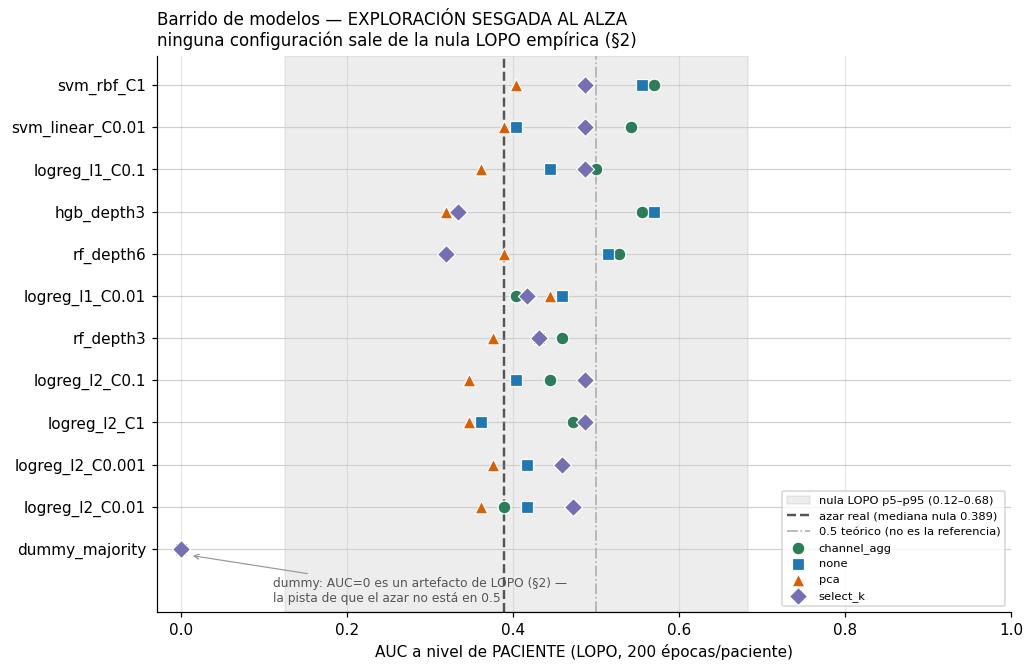

In [6]:
# --- FIGURA 2: AUC de paciente por clasificador x estrategia de reduccion ---
reductions = ["channel_agg", "none", "pca", "select_k"]
red_colors = {"channel_agg": "#2c7d59", "none": "#1f77b4",
              "pca": "#d95f02", "select_k": "#7570b3"}
red_markers = {"channel_agg": "o", "none": "s", "pca": "^", "select_k": "D"}

order = (grid_200.groupby("classifier")["patient_auc"].mean()
         .sort_values().index.tolist())
ypos = {name: i for i, name in enumerate(order)}

fig, ax = plt.subplots(figsize=(9.5, 6.2))
add_lopo_null_reference(ax, orient="x")

for red in reductions:
    sub = grid_200[grid_200["reduction"] == red]
    ax.scatter(sub["patient_auc"], [ypos[c] for c in sub["classifier"]],
               s=70, marker=red_markers[red], color=red_colors[red],
               edgecolor="white", linewidth=0.8, zorder=3, label=red)

for name, i in ypos.items():
    ax.axhline(i, color="#dddddd", lw=0.7, zorder=0)

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlim(-0.03, 1.0)
ax.set_xlabel("AUC a nivel de PACIENTE (LOPO, 200 épocas/paciente)")
ax.set_ylabel("")
ax.set_title("Barrido de modelos — EXPLORACIÓN SESGADA AL ALZA\n"
             "ninguna configuración sale de la nula LOPO empírica (§2)",
             fontsize=11, loc="left")
ax.set_ylim(-1.5, len(order) - 0.3)
ax.annotate("dummy: AUC=0 es un artefacto de LOPO (§2) —\nla pista de que el azar no está en 0.5",
            xy=(0.01, ypos["dummy_majority"] - 0.15), xytext=(0.11, -1.0),
            fontsize=8, color="#555555", va="center",
            arrowprops=dict(arrowstyle="->", color="#999999", lw=0.8))
ax.legend(loc="lower right", frameon=True, fontsize=7.5)
fig.tight_layout()
plt.show()

**Lectura de la figura 2.** **Las 68 configuraciones no-*dummy* caen dentro de la banda p5–p95 de la
nula; ninguna la supera.** La mediana del barrido (0.451) está incluso algo por encima del azar real
(0.389) — coherente con "los modelos captan algo mínimo, o nada, pero desde luego nada que destaque
del ruido".

Nótese cómo cambia la historia al usar la referencia correcta: contra el 0.5 teórico parecía que
**49 de 68 configuraciones iban "peor que el azar"**, un resultado alarmante y falso. Contra la nula
empírica, la mayoría está donde debe estar.

La ordenación entre clasificadores no es interpretable: mover un solo paciente de lado cambia el AUC
en ~0.06, y la sd del ruido es 0.17. La estrategia de reducción tampoco separa nada de forma
consistente — coherente con la hipótesis de que **no hay señal que extraer**, no con la de que
"faltaba el modelo adecuado".

## 4. ¿Ayuda usar más épocas por paciente?

Cada paciente aporta 2 000 épocas de 10 s, pero **las épocas de un mismo paciente no son
observaciones independientes**: son el mismo cerebro medido muchas veces. Si la señal fuese real, más
épocas deberían estabilizar la probabilidad agregada del paciente y mejorar (o al menos no empeorar)
el AUC. Si lo que hay es ruido, el número de épocas no cambiará nada sistemáticamente.

El sub-barrido `modeling_sweep_epochs.csv` fija la reducción (`channel_agg`) y varía sólo el número
de épocas: **50 / 200 / 500 / 2000**.

El panel izquierdo (AUC de paciente, LOPO) lleva la **nula empírica de §2**. El derecho (AUC de
época) sólo lleva la línea de 0.5: la nula LOPO **no se midió a nivel de época** y no sería
comparable, así que ahí el 0.5 se muestra únicamente como orientación visual.

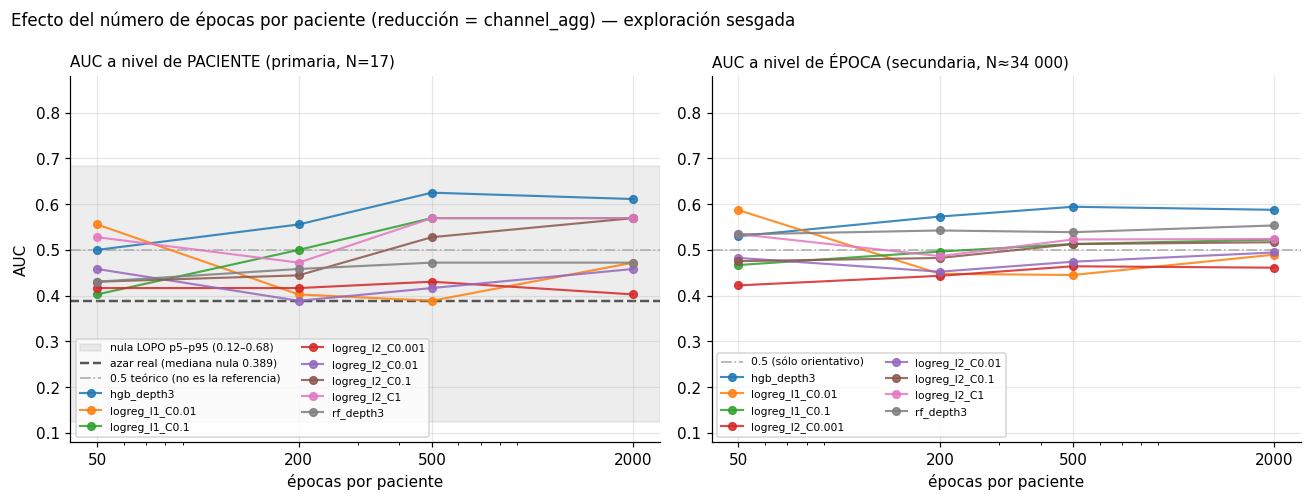

AUC de paciente por clasificador y nº de épocas:
n_epochs_per_patient   50     200    500    2000
classifier                                      
hgb_depth3            0.500  0.556  0.625  0.611
logreg_l1_C0.01       0.556  0.403  0.389  0.472
logreg_l1_C0.1        0.403  0.500  0.569  0.569
logreg_l2_C0.001      0.417  0.417  0.431  0.403
logreg_l2_C0.01       0.458  0.389  0.417  0.458
logreg_l2_C0.1        0.431  0.444  0.528  0.569
logreg_l2_C1          0.528  0.472  0.569  0.569
rf_depth3             0.431  0.458  0.472  0.472


In [7]:
# --- FIGURA 3: efecto del numero de epocas por paciente ---------------------
ep = sweep_epochs[sweep_epochs["classifier"] != "dummy_majority"]
n_levels = sorted(ep["n_epochs_per_patient"].unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)

for ax, metric, title in zip(
    axes,
    ["patient_auc", "epoch_auc"],
    ["AUC a nivel de PACIENTE (primaria, N=17)", "AUC a nivel de ÉPOCA (secundaria, N≈34 000)"],
):
    if metric == "patient_auc":
        add_lopo_null_reference(ax, orient="y", label=True)
    else:
        ax.axhline(0.5, color="#b0b0b0", ls="-.", lw=1.1, label="0.5 (sólo orientativo)")
    for clf, sub in ep.groupby("classifier"):
        sub = sub.sort_values("n_epochs_per_patient")
        ax.plot(sub["n_epochs_per_patient"], sub[metric], marker="o", ms=5,
                lw=1.4, alpha=0.85, label=clf)
    ax.set_xscale("log")
    ax.set_xticks(n_levels)
    ax.set_xticklabels([str(n) for n in n_levels])
    ax.set_xlabel("épocas por paciente")
    ax.set_ylim(0.08, 0.88)
    ax.set_title(title, fontsize=10, loc="left")
    ax.legend(fontsize=7, ncol=2, loc="lower left", frameon=True)

axes[0].set_ylabel("AUC")
fig.suptitle("Efecto del número de épocas por paciente (reducción = channel_agg) — exploración sesgada",
             fontsize=11, x=0.01, ha="left")
fig.tight_layout()
plt.show()

pivot = (ep.pivot_table(index="classifier", columns="n_epochs_per_patient",
                        values="patient_auc")
           .round(3))
print("AUC de paciente por clasificador y nº de épocas:")
print(pivot.to_string())

**Lectura de la figura 3.** No hay tendencia monótona: pasar de 50 a 2 000 épocas (40× más datos por
paciente) no mueve el AUC de paciente de forma sistemática. Esto confirma en la práctica el
argumento del **N efectivo**: el estudio tiene **17 observaciones independientes**, no 34 000. Multiplicar
épocas multiplica filas, no información.

Consecuencia de diseño: el modelo congelado usa **200 épocas/paciente**, no las 2 000. Menos épocas
no es peor y el coste de cómputo baja un orden de magnitud.

El panel derecho muestra el AUC a nivel de época. Se reporta **sólo por transparencia**: su N es
engañoso y jamás debe presentarse como el resultado del trabajo ni usarse para calcular intervalos
de confianza.

## 5. El resultado honesto — validación cruzada anidada

### Qué es y por qué es la estimación válida

En el barrido, el modelo ganador se elige **mirando la misma métrica que luego se informa**. Eso
contamina el número: parte de lo que se informa es la suerte del ganador.

La **CV anidada** rompe ese círculo. Tiene dos bucles:

- **Bucle externo (LOPO, 17 folds):** se aparta **un paciente entero**. Ese paciente no participa en
  nada de lo que ocurra dentro.
- **Bucle interno (sólo con los 16 restantes):** se comparan los 6 candidatos y se elige uno.
- El modelo elegido se entrena con los 16 y se aplica **una sola vez** al paciente apartado.

Así, cada una de las 17 probabilidades *out-of-fold* proviene de un modelo que **nunca vio a ese
paciente**, ni para entrenar ni para elegir. Es la separación a nivel de sujeto llevada hasta la
selección de modelo — la columna vertebral anti-*leakage* de esta fase.

**En los 17 folds externos se eligió siempre `hgb_depth3`.** Que el ganador no baile es lo único
tranquilizador del panel: al menos la elección es estable.

In [8]:
from sklearn.metrics import roc_curve  # noqa: E402

# Se recalculan las metricas y el IC desde el CSV con las MISMAS funciones que
# produjeron los numeros guardados: si algo se hubiera movido, saltaria aqui.
metrics_live = val.patient_level_metrics(patients)
ci = val.bootstrap_ci_patient_level(patients, n_boot=2000, seed=42)

print("Metricas recalculadas desde el CSV (deben coincidir con la ficha del modelo):")
for key in ("roc_auc", "balanced_accuracy", "sensitivity", "specificity", "brier_score"):
    ok = "OK" if abs(metrics_live[key] - nested_metrics[key]) < 1e-9 else "MISMATCH"
    print(f"  {key:20s} {metrics_live[key]:.4f}   [{ok}]")
print()
print("IC 95% por bootstrap REMUESTREANDO PACIENTES (no epocas):")
print(ci.to_string(index=False))

Metricas recalculadas desde el CSV (deben coincidir con la ficha del modelo):
  roc_auc              0.5556   [OK]
  balanced_accuracy    0.6250   [OK]
  sensitivity          1.0000   [OK]
  specificity          0.2500   [OK]
  brier_score          0.2519   [OK]

IC 95% por bootstrap REMUESTREANDO PACIENTES (no epocas):
           metric    point   ci_low  ci_high  n_valid  n_boot  n_patients
          roc_auc 0.555556 0.242424 0.848485     2000    2000          17
balanced_accuracy 0.625000 0.500000 0.785714     2000    2000          17
      sensitivity 1.000000 1.000000 1.000000     2000    2000          17
      specificity 0.250000 0.000000 0.571429     2000    2000          17


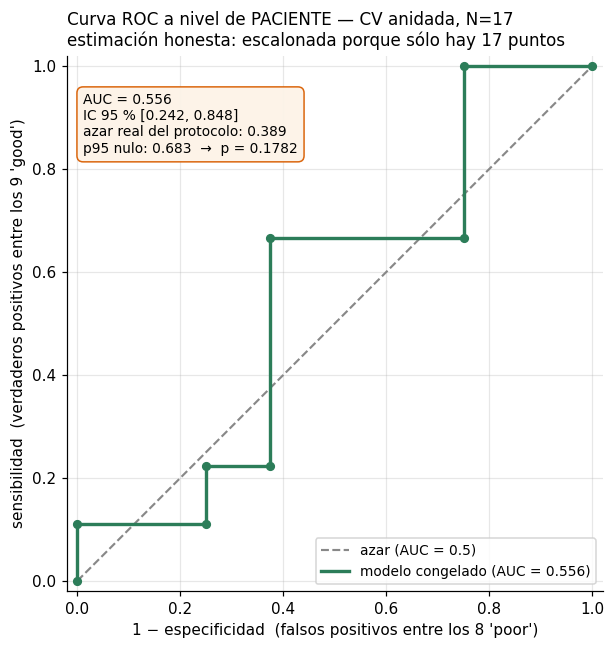

Dos preguntas DISTINTAS, misma respuesta:
  1) incertidumbre del estimador -> IC 95% bootstrap [0.242, 0.848]  (contiene el azar real 0.389)
  2) distancia al azar del protocolo -> p empirico = 0.1782  (observado 0.556 < p95 nulo 0.683)


In [9]:
# --- FIGURA 4: curva ROC a nivel de paciente (17 puntos) --------------------
y_true = patients["y_true"].to_numpy(int)
y_prob = patients["prob_good"].to_numpy(float)
fpr, tpr, thr = roc_curve(y_true, y_prob)

auc_row = ci[ci["metric"] == "roc_auc"].iloc[0]

fig, ax = plt.subplots(figsize=(6.2, 6))
ax.plot([0, 1], [0, 1], ls="--", color=C_CHANCE, lw=1.4, label="azar (AUC = 0.5)")
ax.step(fpr, tpr, where="post", color=C_MODEL, lw=2.2,
        label=f"modelo congelado (AUC = {auc_row['point']:.3f})")
ax.plot(fpr, tpr, "o", color=C_MODEL, ms=5, zorder=3)

ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.set_xlabel("1 − especificidad  (falsos positivos entre los 8 'poor')")
ax.set_ylabel("sensibilidad  (verdaderos positivos entre los 9 'good')")
ax.set_title("Curva ROC a nivel de PACIENTE — CV anidada, N=17\n"
             "estimación honesta: escalonada porque sólo hay 17 puntos",
             fontsize=11, loc="left")
ax.legend(loc="lower right", fontsize=9)
ax.text(0.03, 0.93,
        f"AUC = {auc_row['point']:.3f}\n"
        f"IC 95 % [{auc_row['ci_low']:.3f}, {auc_row['ci_high']:.3f}]\n"
        f"azar real del protocolo: {lopo_p50:.3f}\n"
        f"p95 nulo: {lopo_p95:.3f}  →  p = {lopo_p:.4f}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.45", fc="#fdf3e7", ec="#d95f02", alpha=0.95))
fig.tight_layout()
plt.show()

print("Dos preguntas DISTINTAS, misma respuesta:")
print(f"  1) incertidumbre del estimador -> IC 95% bootstrap "
      f"[{auc_row['ci_low']:.3f}, {auc_row['ci_high']:.3f}]  (contiene el azar real {lopo_p50:.3f})")
print(f"  2) distancia al azar del protocolo -> p empirico = {lopo_p:.4f}  "
      f"(observado {LOPO_OBS:.3f} < p95 nulo {lopo_p95:.3f})")

**Lectura de la figura 4 — y el matiz de la diagonal.** La curva serpentea alrededor de la diagonal.
Cuidado: **esa diagonal es el 0.5 teórico, no el azar de este protocolo** (0.389). Se dibuja porque
es la convención universal de la curva ROC y porque omitirla confundiría más de lo que aclara, pero
el juicio estadístico correcto es el de §2: el observado está **por encima** del azar real y **por
debajo** de su percentil 95.

El **IC 95 % del AUC va de 0.242 a 0.848**: incluye tanto "peor que lanzar una moneda" como
"bastante bueno". Con 17 sujetos, el estudio simplemente **no tiene resolución** para distinguir esas
dos posibilidades.

Son dos preguntas distintas que conviene no mezclar:

- el **IC bootstrap** responde *"¿cuánto se movería este número si repitiera el estudio con otros
  17 pacientes?"* — respuesta: muchísimo;
- el **p-valor de permutación** responde *"¿podría el azar de este protocolo haber producido este
  número?"* — respuesta: sí, sin dificultad.

Nótese la anchura del intervalo. Es la consecuencia directa de remuestrear **pacientes** y no
épocas. Si el bootstrap se hiciera sobre las 34 000 épocas saldría algo como `[0.54, 0.57]` — un
intervalo estrecho y **falso**, porque fingiría que hay 34 000 cerebros independientes.

## 6. Matriz de confusión — el modelo dice "good" casi siempre

Con el umbral de decisión en 0.5, ¿qué decide realmente el modelo?

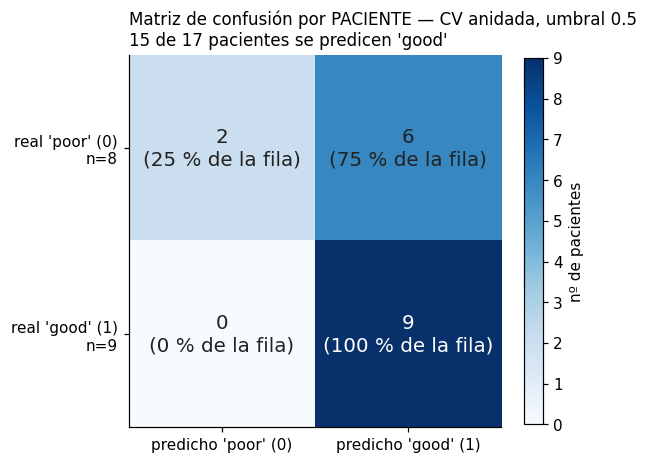

sensibilidad (TP/(TP+FN)) = 9/9 = 1.000   -> acierta TODOS los que despertaron...
especificidad (TN/(TN+FP)) = 2/8 = 0.250   -> ...pero sólo 2 de los 8 que no despertaron
balanced accuracy         = 0.625   (IC 95% [0.500, 0.786])
predichos 'good'          = 15/17 = 88.2%   (tasa real de 'good' = 52.9%)


In [10]:
# --- FIGURA 5: matriz de confusion a nivel de paciente ----------------------
tn, fp = int(nested_metrics["tn"]), int(nested_metrics["fp"])
fn, tp = int(nested_metrics["fn"]), int(nested_metrics["tp"])
cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5.6, 5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
for i in range(2):
    for j in range(2):
        pct = 100 * cm[i, j] / cm[i].sum()
        ax.text(j, i, f"{cm[i, j]}\n({pct:.0f} % de la fila)",
                ha="center", va="center", fontsize=13,
                color="white" if cm[i, j] > cm.max() * 0.72 else "#222222")

ax.set_xticks([0, 1], ["predicho 'poor' (0)", "predicho 'good' (1)"])
ax.set_yticks([0, 1], ["real 'poor' (0)\nn=8", "real 'good' (1)\nn=9"])
ax.set_title("Matriz de confusión por PACIENTE — CV anidada, umbral 0.5\n"
             "15 de 17 pacientes se predicen 'good'",
             fontsize=11, loc="left")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75, label="nº de pacientes")
fig.tight_layout()
plt.show()

print(f"sensibilidad (TP/(TP+FN)) = {tp}/{tp + fn} = {nested_metrics['sensitivity']:.3f}"
      "   -> acierta TODOS los que despertaron...")
print(f"especificidad (TN/(TN+FP)) = {tn}/{tn + fp} = {nested_metrics['specificity']:.3f}"
      "   -> ...pero sólo 2 de los 8 que no despertaron")
print(f"balanced accuracy         = {nested_metrics['balanced_accuracy']:.3f}"
      f"   (IC 95% [{ci[ci.metric == 'balanced_accuracy'].ci_low.iloc[0]:.3f}, "
      f"{ci[ci.metric == 'balanced_accuracy'].ci_high.iloc[0]:.3f}])")
print(f"predichos 'good'          = {fp + tp}/17 = {(fp + tp) / 17:.1%}"
      f"   (tasa real de 'good' = {y_true.mean():.1%})")

**Lectura de la figura 5.** Sensibilidad 1.000 suena magnífica hasta que se mira la otra celda:
**especificidad 0.250**, con IC 95 % [0.000, 0.571]. El modelo dice "despertará" a 15 de 17
pacientes. Una regla trivial que dijera "*good*" a todo el mundo obtendría sensibilidad 1.000,
especificidad 0.000 y accuracy 53 % — el modelo está apenas dos pacientes por encima de esa regla.

**Y en esta aplicación el error grave es justamente el que domina.** Predecir "despertará" a quien
no lo hará es un falso positivo; el error verdaderamente peligroso es el inverso —decir "no
despertará" a alguien que sí habría despertado— y este modelo casi nunca dice "no despertará", de
modo que su aparente seguridad clínica es sólo el reflejo de su incapacidad de discriminar.

## 7. Las 17 probabilidades, paciente a paciente

Ésta es la figura que mejor comunica el resultado. Cada barra es un paciente: su **confianza
predicha** (probabilidad de *good*, promediada sobre sus 200 épocas), coloreada por su **desenlace
real**. Si el modelo discriminara, los azules se agolparían a la derecha y los naranjas a la
izquierda.

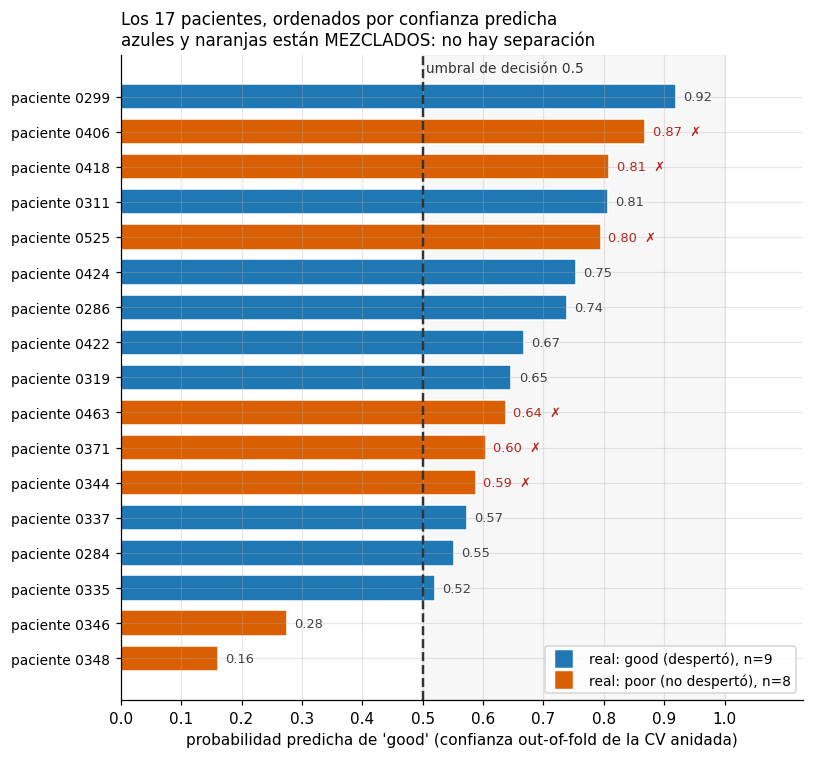

Probabilidad media predicha por clase real:
  good (n=9): 0.687
  poor (n=8): 0.593
  separación entre medias: +0.094

Rango de probabilidades: [0.161, 0.920]  — 15/17 por encima del umbral


In [11]:
# --- FIGURA 6: probabilidad predicha por paciente ---------------------------
pdf = patients.sort_values("prob_good").reset_index(drop=True)
colors = [C_GOOD if t == 1 else C_POOR for t in pdf["y_true"]]

fig, ax = plt.subplots(figsize=(7.5, 7))
bars = ax.barh(np.arange(len(pdf)), pdf["prob_good"], color=colors,
               edgecolor="white", height=0.72)
ax.axvline(0.5, color="#333333", ls="--", lw=1.6)
ax.text(0.505, len(pdf) - 0.3, "umbral de decisión 0.5", fontsize=9, color="#333333")
ax.axvspan(0.5, 1.0, color="#333333", alpha=0.04, zorder=0)

for i, (prob, err) in enumerate(zip(pdf["prob_good"],
                                    (pdf["prob_good"] >= 0.5) != (pdf["y_true"] == 1))):
    ax.text(prob + 0.012, i, f"{prob:.2f}" + ("  ✗" if err else ""),
            va="center", fontsize=8.5,
            color="#b3271e" if err else "#444444")

ax.set_yticks(np.arange(len(pdf)))
ax.set_yticklabels([f"paciente {p}" for p in pdf["patient_id"]], fontsize=9)
ax.set_xlim(0, 1.13)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.set_xlabel("probabilidad predicha de 'good' (confianza out-of-fold de la CV anidada)")
ax.set_title("Los 17 pacientes, ordenados por confianza predicha\n"
             "azules y naranjas están MEZCLADOS: no hay separación",
             fontsize=11, loc="left")
ax.legend(handles=[Line2D([], [], marker="s", ls="", ms=10, color=C_GOOD,
                          label="real: good (despertó), n=9"),
                   Line2D([], [], marker="s", ls="", ms=10, color=C_POOR,
                          label="real: poor (no despertó), n=8")],
          loc="lower right", fontsize=9, frameon=True)
fig.tight_layout()
plt.show()

print("Probabilidad media predicha por clase real:")
print(f"  good (n=9): {pdf.loc[pdf.y_true == 1, 'prob_good'].mean():.3f}")
print(f"  poor (n=8): {pdf.loc[pdf.y_true == 0, 'prob_good'].mean():.3f}")
print(f"  separación entre medias: "
      f"{pdf.loc[pdf.y_true == 1, 'prob_good'].mean() - pdf.loc[pdf.y_true == 0, 'prob_good'].mean():+.3f}")
print(f"\nRango de probabilidades: [{pdf.prob_good.min():.3f}, {pdf.prob_good.max():.3f}]  "
      f"— {(pdf.prob_good >= 0.5).sum()}/17 por encima del umbral")

**Lectura de la figura 6 — la más elocuente del notebook.** Los dos colores están intercalados a lo
largo de todo el eje. El paciente con la **segunda probabilidad más alta** (0406, 0.87) **no
despertó**; el paciente *good* peor puntuado (0335, 0.52) queda por debajo de **seis** *poor*. La
diferencia entre las medias de ambos grupos es de apenas unas centésimas, muy por debajo de la
dispersión dentro de cada grupo.

Sólo dos pacientes (0346 y 0348) caen por debajo del umbral, y ambos son efectivamente *poor*: son
los dos únicos aciertos que sostienen la especificidad de 0.250. **Dos pacientes.** Basta que uno de
ellos hubiera caído del otro lado para que la especificidad bajara a 0.125 — exactamente la
fragilidad que refleja el IC [0.000, 0.571].

## 8. Calibración — ¿significa algo el número de confianza?

El entregable no es "despertará", es "despertará **con confianza 0.8**". Ese número sólo es
utilizable si está **calibrado**: de todos los pacientes a los que el modelo asigna 0.8, deberían
despertar aproximadamente 8 de cada 10. Si no, el 0.8 es decorativo y usarlo para decidir sobre
soporte vital sería peligroso.

- **Brier score**: error cuadrático medio entre probabilidad y realidad (0 = perfecto). Mezcla
  discriminación y calibración.
- **ECE** (*expected calibration error*): desviación media respecto a la diagonal ideal, ponderada
  por cuántos pacientes hay en cada caja.

⚠️ **Con 17 pacientes la curva es anecdótica** (4 cajas de ~4 pacientes). Sirve como control de
sanidad y para declarar honestamente que la calibración **no se puede establecer** con este N.

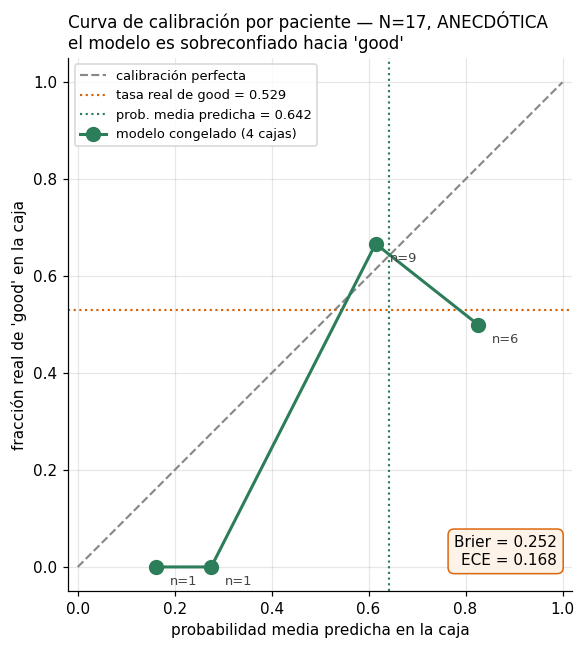

 bin  bin_low  bin_high  n_patients  mean_predicted  fraction_good
   0     0.00      0.25           1           0.161          0.000
   1     0.25      0.50           1           0.275          0.000
   2     0.50      0.75           9           0.615          0.667
   3     0.75      1.00           6           0.826          0.500

Brier = 0.252   (un modelo que dijera siempre 0.529 daria 0.249)
ECE   = 0.168
prob. media predicha 0.642  vs  tasa real de good 0.529   -> sesgo +0.113


In [12]:
# --- FIGURA 7: curva de calibracion -----------------------------------------
cal, curve = val.calibration_report(patients, n_bins=4)
curve_ok = curve.dropna(subset=["mean_predicted"])

fig, ax = plt.subplots(figsize=(6.4, 6))
ax.plot([0, 1], [0, 1], ls="--", color=C_CHANCE, lw=1.4, label="calibración perfecta")
ax.axhline(cal["observed_good_rate"], color=C_POOR, ls=":", lw=1.4,
           label=f"tasa real de good = {cal['observed_good_rate']:.3f}")
ax.axvline(cal["mean_predicted_prob"], color=C_MODEL, ls=":", lw=1.4,
           label=f"prob. media predicha = {cal['mean_predicted_prob']:.3f}")

ax.plot(curve_ok["mean_predicted"], curve_ok["fraction_good"], "-o",
        color=C_MODEL, lw=2, ms=9, zorder=3, label="modelo congelado (4 cajas)")
for _, r in curve_ok.iterrows():
    ax.annotate(f"n={int(r['n_patients'])}",
                (r["mean_predicted"], r["fraction_good"]),
                textcoords="offset points", xytext=(9, -12), fontsize=8.5, color="#444444")

ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.set_xlabel("probabilidad media predicha en la caja")
ax.set_ylabel("fracción real de 'good' en la caja")
ax.set_title("Curva de calibración por paciente — N=17, ANECDÓTICA\n"
             "el modelo es sobreconfiado hacia 'good'", fontsize=11, loc="left")
ax.legend(loc="upper left", fontsize=8.5)
ax.text(0.97, 0.05,
        f"Brier = {cal['brier_score']:.3f}\nECE = {cal['expected_calibration_error']:.3f}",
        transform=ax.transAxes, ha="right", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="#fdf3e7", ec="#d95f02", alpha=0.95))
fig.tight_layout()
plt.show()

print(curve.round(3).to_string(index=False))
print()
print(f"Brier = {cal['brier_score']:.3f}   (un modelo que dijera siempre 0.529 daria "
      f"{y_true.mean() * (1 - y_true.mean()):.3f})")
print(f"ECE   = {cal['expected_calibration_error']:.3f}")
print(f"prob. media predicha {cal['mean_predicted_prob']:.3f}  vs  tasa real de good "
      f"{cal['observed_good_rate']:.3f}   -> sesgo +{cal['mean_predicted_prob'] - cal['observed_good_rate']:.3f}")

**Lectura de la figura 7.** La curva queda **por debajo** de la diagonal en el tramo alto: entre los
6 pacientes a los que el modelo asignó ~0.83 de confianza, sólo despertó la mitad. El modelo promete
más de lo que cumple — es **sobreconfiado hacia "good"**, con una probabilidad media predicha de
0.642 frente a una tasa real de 0.529.

El Brier de **0.252** es prácticamente el de un modelo que dijera siempre "0.529" (0.249): otra vez,
la confianza no aporta información por encima de la tasa base. Con 4 cajas de 1, 1, 9 y 6 pacientes,
esta curva **no puede sostener ninguna afirmación fuerte** — se incluye para dejar declarado que la
calibración queda sin establecer.

## 9. Control negativo I — test de permutación

**La pregunta del jurado:** "¿cómo sé que ese número no es un artefacto?"

El test de permutación destruye a propósito la relación entre EEG y desenlace: **baraja las
etiquetas** y vuelve a correr todo el procedimiento. Si con etiquetas barajadas el modelo sigue
acertando, es que nunca estaba usando la señal clínica, sino una fuga.

**Se baraja a nivel de PACIENTE, no de época** (200 permutaciones). Barajar las 34 000 etiquetas de
época repartiría ambas clases *dentro* de cada paciente y rompería la estructura de grupo que
precisamente queremos conservar bajo la hipótesis nula. La hipótesis nula correcta es *"el desenlace
del paciente no tiene relación con su EEG"*, así que se permuta el vector de 17 etiquetas — lo que
además conserva el balance 9/8.

**⚠️ Detalle a declarar — este control NO usa el protocolo primario.** El AUC observado aquí es
**0.639**, no 0.556. No es una contradicción: este test usa un `StratifiedGroupKFold` de **5 folds**
sobre `hgb_depth3` fijo (repetir LOPO 201 veces era inasumible en coste), mientras que la estimación
honesta usa LOPO con selección anidada. **Son dos protocolos distintos y sus números no son
intercambiables** — se ve en las nulas: la de 5 folds está centrada en 0.478 y la de LOPO en 0.389.
Cada observado se juzga **contra su propia nula**; el juicio del protocolo primario es el de §2.

Los 200 valores nulos están guardados en `data_processed/permutation_null_aucs.npy`: el histograma
de abajo es **la distribución real**, no una aproximación.

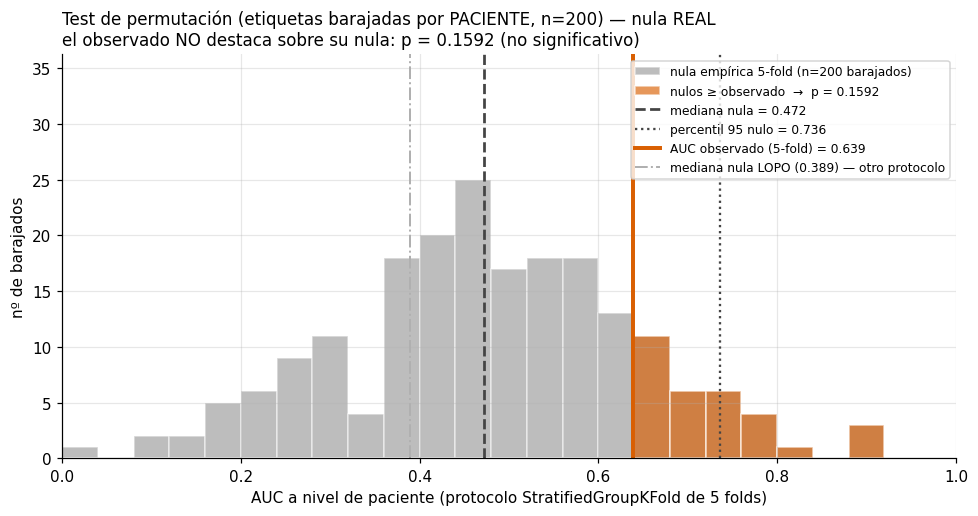

nula 5-fold: media=0.478  sd=0.162  mediana=0.472  n=200
percentiles: p5=0.208  p50=0.472  p95=0.736
observado 0.639  ->  z = +0.99 sd sobre la media nula
p empirico = 0.1592  ->  NO se rechaza la hipotesis nula (umbral habitual 0.05)
p minimo alcanzable con n=200 permutaciones: 0.0050

comparacion de las DOS nulas (protocolos distintos, no intercambiables):
  5-fold : media 0.478  sd 0.162  p95 0.736
  LOPO   : media 0.388  sd 0.171  p95 0.683


In [13]:
# --- FIGURA 8: distribucion nula REAL del test de permutacion ---------------
# Valores empiricos guardados en disco (200 barajados, StratifiedGroupKFold(5)).
PERM_OBSERVED = 0.639                      # observado de ESTE protocolo, no el LOPO
PERM_P = frozen["permutation_p_value"]
perm_mean, perm_sd = perm_null.mean(), perm_null.std(ddof=1)
perm_p5, perm_p50, perm_p95 = np.percentile(perm_null, [5, 50, 95])

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(perm_null, bins=25, range=(0, 1), color=C_CHANCE, alpha=0.55,
        edgecolor="white", label=f"nula empírica 5-fold (n={perm_null.size} barajados)")
ax.hist(perm_null[perm_null >= PERM_OBSERVED], bins=25, range=(0, 1),
        color=C_POOR, alpha=0.65, edgecolor="white",
        label=f"nulos ≥ observado  →  p = {PERM_P:.4f}")

ax.axvline(perm_p50, color="#444444", ls="--", lw=1.8,
           label=f"mediana nula = {perm_p50:.3f}")
ax.axvline(perm_p95, color="#444444", ls=":", lw=1.5,
           label=f"percentil 95 nulo = {perm_p95:.3f}")
ax.axvline(PERM_OBSERVED, color=C_POOR, lw=2.6,
           label=f"AUC observado (5-fold) = {PERM_OBSERVED:.3f}")
ax.axvline(lopo_p50, color="#b0b0b0", ls="-.", lw=1.3,
           label=f"mediana nula LOPO ({lopo_p50:.3f}) — otro protocolo")

ax.set_xlim(0, 1)
ax.set_ylim(0, np.histogram(perm_null, bins=25, range=(0, 1))[0].max() * 1.45)
ax.set_xlabel("AUC a nivel de paciente (protocolo StratifiedGroupKFold de 5 folds)")
ax.set_ylabel("nº de barajados")
ax.set_title("Test de permutación (etiquetas barajadas por PACIENTE, n=200) — nula REAL\n"
             f"el observado NO destaca sobre su nula: p = {PERM_P:.4f} (no significativo)",
             fontsize=11, loc="left")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

z = (PERM_OBSERVED - perm_mean) / perm_sd
print(f"nula 5-fold: media={perm_mean:.3f}  sd={perm_sd:.3f}  mediana={perm_p50:.3f}  n={perm_null.size}")
print(f"percentiles: p5={perm_p5:.3f}  p50={perm_p50:.3f}  p95={perm_p95:.3f}")
print(f"observado {PERM_OBSERVED:.3f}  ->  z = {z:+.2f} sd sobre la media nula")
print(f"p empirico = {PERM_P:.4f}  ->  NO se rechaza la hipotesis nula (umbral habitual 0.05)")
print(f"p minimo alcanzable con n={perm_null.size} permutaciones: {1 / (1 + perm_null.size):.4f}")
print(f"\ncomparacion de las DOS nulas (protocolos distintos, no intercambiables):")
print(f"  5-fold : media {perm_mean:.3f}  sd {perm_sd:.3f}  p95 {perm_p95:.3f}")
print(f"  LOPO   : media {lopo_null.mean():.3f}  sd {lopo_null.std(ddof=1):.3f}  p95 {lopo_p95:.3f}")

**Lectura de la figura 8.** El observado (0.639) cae a **≈1 desviación típica** de la media nula
(0.478 ± 0.162) y **por debajo del percentil 95 (0.736)**: dentro del rango que produce el azar
puro. El p-valor empírico es **0.1592**, lejos de cualquier umbral de significación. Traducido: **con
etiquetas barajadas al azar, un resultado tan bueno como el observado aparece en 1 de cada ~6
intentos.**

Tres observaciones importantes:

1. **La media nula es 0.478, no 0.5** — y la de LOPO es 0.389. Ni siquiera un `StratifiedGroupKFold`
   deja el azar exactamente en 0.5 con 17 sujetos. Confirma la tesis de §2: **el azar hay que
   medirlo, no suponerlo**, y hay que medirlo *para cada protocolo*.
2. **El test es tranquilizador en un sentido y desalentador en el otro**: no detecta ninguna fuga
   grosera (con etiquetas barajadas el rendimiento efectivamente cae al azar de su protocolo), pero
   tampoco detecta señal.
3. **Los dos controles coinciden**: p = 0.1592 (5 folds) y p = 0.1782 (LOPO, §2). Dos protocolos
   independientes, la misma conclusión.

## 10. Control negativo II — la sonda de identidad de paciente

**Pregunta:** ¿cuánta información sobre *qué paciente es* llevan las features, independientemente de
su desenlace?

La sonda entrena un clasificador para predecir el **ID del paciente** (17 clases) a partir de una
única época. El azar sería **1/17 = 0.059**.

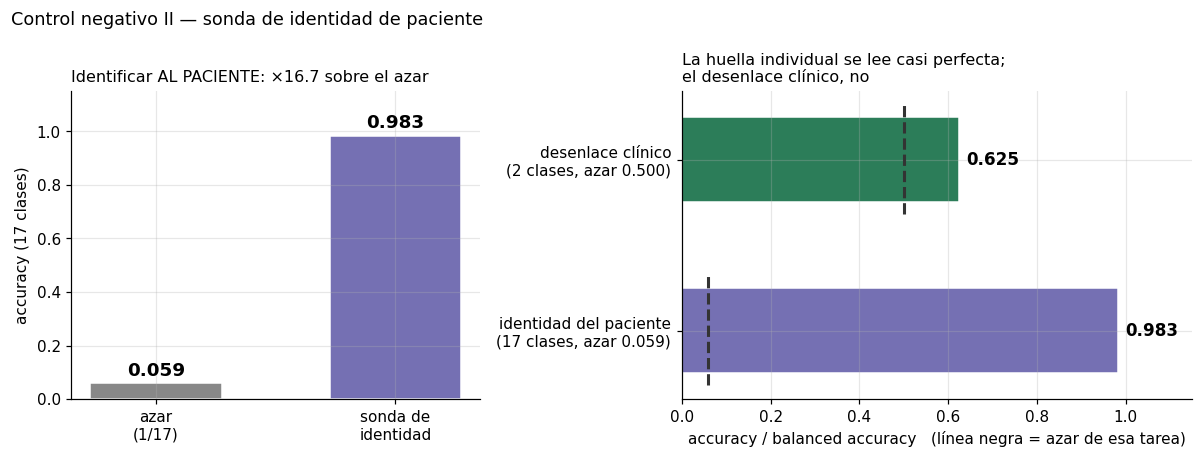

accuracy de la sonda : 0.983
azar (1/17)          : 0.059
razon sobre el azar  : x16.7


In [14]:
# --- FIGURA 9: sonda de identidad de paciente -------------------------------
probe_acc = frozen["patient_identity_probe_accuracy"]
chance = 1 / frozen["n_development_patients"]
ratio = probe_acc / chance

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2),
                         gridspec_kw={"width_ratios": [1, 1.25]})

ax = axes[0]
ax.bar(["azar\n(1/17)", "sonda de\nidentidad"], [chance, probe_acc],
       color=[C_CHANCE, "#7570b3"], width=0.55, edgecolor="white")
for i, v in enumerate([chance, probe_acc]):
    ax.text(i, v + 0.03, f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("accuracy (17 clases)")
ax.set_title(f"Identificar AL PACIENTE: ×{ratio:.1f} sobre el azar", fontsize=10.5, loc="left")

ax = axes[1]
tasks = ["identidad del paciente\n(17 clases, azar 0.059)",
         "desenlace clínico\n(2 clases, azar 0.500)"]
vals = [probe_acc, nested_metrics["balanced_accuracy"]]
chances = [chance, 0.5]
ax.barh(tasks, vals, color=["#7570b3", C_MODEL], height=0.5, edgecolor="white")
for i, (v, c) in enumerate(zip(vals, chances)):
    ax.plot([c, c], [i - 0.32, i + 0.32], color="#333333", ls="--", lw=2)
    ax.text(v + 0.015, i, f"{v:.3f}", va="center", fontsize=11, fontweight="bold")
ax.set_xlim(0, 1.15)
ax.set_xlabel("accuracy / balanced accuracy   (línea negra = azar de esa tarea)")
ax.set_title("La huella individual se lee casi perfecta;\nel desenlace clínico, no",
             fontsize=10.5, loc="left")

fig.suptitle("Control negativo II — sonda de identidad de paciente", fontsize=11.5, x=0.01, ha="left")
fig.tight_layout()
plt.show()

print(f"accuracy de la sonda : {probe_acc:.3f}")
print(f"azar (1/17)          : {chance:.3f}")
print(f"razon sobre el azar  : x{ratio:.1f}")

### Por qué esto es material obligatorio de "Limitaciones"

Con **0.983 de accuracy** en una tarea de 17 clases cuyo azar es 0.059, la conclusión es
inequívoca: **una sola época de 10 s basta para reconocer de qué paciente proviene**. Las features
espectrales llevan una **huella individual fortísima** — anatomía del cráneo, impedancia de los
electrodos, medicación, ruido del entorno de esa cama concreta.

Las tres consecuencias que hay que saber defender:

1. **Explica por qué la separación a nivel de paciente es innegociable.** Si una sola época del
   paciente de test se colara en el entrenamiento, el modelo no aprendería fisiología: memorizaría
   la huella de ese paciente y su etiqueta. Con un ×16.7 sobre el azar, ese *leakage* produciría
   métricas espectaculares y completamente falsas. **La CV agrupada de este notebook lo impide por
   construcción** (verificado explícitamente: 17 folds, cero solapamiento de pacientes).
2. **Explica por qué el problema es difícil.** La variabilidad *entre individuos* es enorme
   comparada con la diferencia *entre desenlaces*. La señal clínica que buscamos vive enterrada bajo
   una fuente de variación mucho más potente que ella.
3. **No es un fallo del pipeline, es una propiedad del EEG.** Pero debe declararse: cualquier
   resultado positivo futuro en este proyecto tendrá que acompañarse de esta sonda para demostrar
   que no es identidad disfrazada de pronóstico.

## 11. Tabla resumen de la Fase 4

In [15]:
summary = pd.DataFrame([
    ("AZAR REAL (mediana nula LOPO)", f"{lopo_p50:.3f}",
     f"p5-p95 [{lopo_p5:.3f}, {lopo_p95:.3f}]",
     "la referencia de este protocolo NO es 0.5"),
    ("AUC (paciente)",       f"{nested_metrics['roc_auc']:.3f}",
     f"[{ci[ci.metric=='roc_auc'].ci_low.iloc[0]:.3f}, {ci[ci.metric=='roc_auc'].ci_high.iloc[0]:.3f}]",
     f"sobre el azar real ({lopo_p50:.3f}) pero < p95 ({lopo_p95:.3f})"),
    ("p (nula LOPO, primaria)", f"{lopo_p:.4f}", "-",
     "no significativo (n=100) -> SIN evidencia de senal"),
    ("Balanced accuracy",    f"{nested_metrics['balanced_accuracy']:.3f}",
     f"[{ci[ci.metric=='balanced_accuracy'].ci_low.iloc[0]:.3f}, {ci[ci.metric=='balanced_accuracy'].ci_high.iloc[0]:.3f}]",
     "el limite inferior es exactamente el azar"),
    ("Sensibilidad",         f"{nested_metrics['sensitivity']:.3f}", "[1.000, 1.000]",
     "acierta los 9 good... prediciendo good casi siempre"),
    ("Especificidad",        f"{nested_metrics['specificity']:.3f}",
     f"[{ci[ci.metric=='specificity'].ci_low.iloc[0]:.3f}, {ci[ci.metric=='specificity'].ci_high.iloc[0]:.3f}]",
     "solo 2 de 8 poor; el IC llega a 0.000"),
    ("Brier score",          f"{nested_metrics['brier_score']:.3f}", "-",
     "equivalente a predecir siempre la tasa base"),
    ("ECE",                  f"{cal['expected_calibration_error']:.3f}", "-",
     "sobreconfiado hacia good; anecdotico con N=17"),
    ("p (permutacion 5-fold)", f"{frozen['permutation_p_value']:.4f}", "-",
     f"otro protocolo (obs 0.639 vs nula {perm_p50:.3f}); misma conclusion"),
    ("Sonda de identidad",   f"{probe_acc:.3f}", "-",
     f"x{ratio:.1f} sobre el azar -> huella individual dominante"),
    ("Mejor AUC del barrido", f"{sweep_u['patient_auc'].max():.3f}", "-",
     f"maximo de ~75 pruebas: SESGADO y aun asi < p95 ({lopo_p95:.3f})"),
], columns=["metrica", "valor", "IC 95% / rango", "lectura"])

print(f"FASE 4 — RESUMEN   (N = {frozen['n_development_patients']} pacientes de desarrollo, "
      f"{int(y_true.sum())} good / {int((1 - y_true).sum())} poor)")
print(f"modelo congelado: {frozen['classifier']} + {frozen['reduction']} "
      f"@ {frozen['epochs_per_patient']} epocas/paciente\n")
print(summary.to_string(index=False))

FASE 4 — RESUMEN   (N = 17 pacientes de desarrollo, 9 good / 8 poor)
modelo congelado: hgb_depth3 + channel_agg @ 200 epocas/paciente

                      metrica  valor        IC 95% / rango                                                    lectura
AZAR REAL (mediana nula LOPO)  0.389 p5-p95 [0.124, 0.683]                  la referencia de este protocolo NO es 0.5
               AUC (paciente)  0.556        [0.242, 0.848]              sobre el azar real (0.389) pero < p95 (0.683)
      p (nula LOPO, primaria) 0.1782                     -         no significativo (n=100) -> SIN evidencia de senal
            Balanced accuracy  0.625        [0.500, 0.786]                  el limite inferior es exactamente el azar
                 Sensibilidad  1.000        [1.000, 1.000]        acierta los 9 good... prediciendo good casi siempre
                Especificidad  0.250        [0.000, 0.571]                      solo 2 de 8 poor; el IC llega a 0.000
                  Brier score  0.252   

## 12. Conclusión — lectura honesta de la Fase 4

### El encuadre correcto: 0.556 NO está "por debajo del azar"

Es el matiz más importante de la fase y hay que tenerlo afilado para la defensa. Contra el 0.5
teórico, un AUC de 0.556 parece "apenas empatar" y la mediana del barrido (0.451) parece "peor que
lanzar una moneda". **Ambas lecturas son falsas**, porque el 0.5 no es el azar de este protocolo.

Medido empíricamente (§2), el azar de LOPO está en **0.389 ± 0.171**. Frente a esa referencia:

- el observado (**0.556**) está **por encima del azar real**, a **+0.98 σ**;
- pero **no supera el percentil 95 nulo (0.683)**, y **p = 0.1782**;
- **ninguna** de las 68 configuraciones del barrido supera ese p95 tampoco.

La afirmación defendible es: ***"por encima del azar real del protocolo, pero dentro de su ruido:
sin evidencia de discriminación"***. Y conviene añadir que el sesgo de LOPO es **conservador** —
deprime el AUC, nunca lo infla— así que **no puede haber fabricado un falso positivo**; a lo sumo
puede haber escondido un efecto pequeño.

### Qué se puede afirmar

**No hay evidencia de discriminación por encima del azar** en el conjunto de desarrollo de 17
pacientes. Cinco líneas de evidencia apuntan en la misma dirección y se sostienen entre sí:

- el observado **no supera el p95 de la nula empírica del protocolo primario** (p = 0.1782);
- el **segundo control de permutación**, con un protocolo distinto (5 folds), coincide (p = 0.1592);
- el **IC 95 % del AUC [0.242, 0.848]** es tan ancho que contiene tanto el azar real como un modelo
  útil;
- la **especificidad de 0.250** muestra que el modelo reproduce el balance de clases (15 de 17
  pacientes predichos *good*) más que discriminar;
- el **mejor AUC del barrido (0.625)** es el máximo de ~75 pruebas y **sigue por debajo del p95
  nulo (0.683)**: exactamente lo que produciría el ruido.

### Qué NO se puede afirmar

Tampoco se ha demostrado que **no** exista señal. Un IC que llega hasta 0.848 es compatible con un
modelo útil; simplemente, **este estudio no tiene resolución para distinguirlo**. Y dado que LOPO
sesga a la baja, un efecto pequeño podría estar quedando enterrado. La conclusión correcta es
*"no concluyente, sesgado hacia la ausencia de señal"*, no *"el EEG no sirve"*.

### Por qué existe el modelo congelado

`models/frozen_model.joblib` **no se congela porque haya señal**. Se congela porque el protocolo de
la Fase 5 exige un modelo y un criterio de decisión **fijados antes de mirar el conjunto *held-out***.
Congelarlo ahora, con este resultado a la vista y por escrito, es lo que hace que la evaluación
*held-out* sea honesta: se hace **una sola vez**, sin margen para reajustar nada. Si en la Fase 5 el
*held-out* diera un resultado brillante, habría que sospechar de él, no celebrarlo.

### Hipótesis de por qué el resultado es negativo

1. **N efectivo = 17, no 34 000.** Es la limitación dominante. Las 2 000 épocas por paciente son el
   mismo cerebro medido muchas veces; la figura 3 lo confirma empíricamente (40× más épocas no mueve
   el AUC). Con 9 vs 8 sujetos, la desviación típica del AUC bajo la nula **medida** es **0.171**, y
   el rango p5–p95 va de 0.124 a 0.683: haría falta un efecto enorme para asomar por encima de ese
   ruido. **Éste es el cuello de botella, no el modelo.**
2. **La huella individual domina la señal clínica.** La sonda identifica al paciente con 0.983 de
   accuracy (×16.7 sobre el azar). La variación *entre individuos* es mucho mayor que la variación
   *entre desenlaces*, y sepulta lo que buscamos.
3. **Las features espectrales pueden ser insuficientes.** Las 380 features son potencias relativas
   por banda, ratios, entropías, Hjorth y estadísticos de forma — descriptores *estacionarios*. Los
   marcadores que la literatura asocia al pronóstico post-paro son en buena medida **patrones
   temporales y de reactividad**: *burst-suppression*, discontinuidad, evolución del trazado a lo
   largo de las horas, respuesta a estímulos. Nada de eso está representado en el vector actual.
4. **La ventana 24–72 h se agrega sin distinguir la hora.** Todas las épocas de un paciente se
   promedian por igual, pero el EEG a las 24 h y a las 72 h no significan lo mismo: la
   **trayectoria** es justamente parte del valor pronóstico, y aplanarla puede estar borrando el
   efecto.
5. **Posible heterogeneidad de la etiqueta.** El desenlace binario *good/poor* condensa un proceso
   clínico complejo (sedación, complicaciones, decisiones de retirada de soporte) que el EEG de esa
   ventana no determina por completo.

### Qué hacer con esto en la tesis

Reportarlo tal cual, en Resultados y en Limitaciones, y encuadrarlo como lo que es: **una prueba de
concepto metodológicamente sólida cuyo resultado es negativo**. El valor entregado no es un
clasificador que funcione — es el **andamiaje de validación honesta** (separación a nivel de
paciente verificada, CV anidada, bootstrap sobre sujetos, **nula empírica del propio protocolo**,
controles negativos, modelo congelado antes de ver el *held-out*) que permite afirmar el resultado
negativo **con confianza**, y que sostendrá cualquier iteración futura con más pacientes o mejores
features.

**Una lección metodológica transferible**, nacida del `dummy_majority` con AUC 0: **nunca se compara
un resultado contra el azar teórico de la métrica; se compara contra el azar medido del protocolo.**
Con N pequeño y validación *leave-one-out*, esos dos números pueden diferir en más de 0.1 — bastante
para convertir un resultado nulo correcto en una conclusión equivocada, en cualquiera de las dos
direcciones. El clasificador tonto no era un trámite: fue el detector que reveló el problema.

---

**Siguiente paso — Fase 5:** aplicar el modelo congelado, **una sola vez**, a los 15 pacientes
*held-out*, que ningún componente de este notebook ha visto. La comparación se hará contra la nula
del protocolo de la Fase 5, no contra 0.5.